In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
custom_palette =['#E50914', '#221f1f', '#141414', '#B20710']
netflix = pd.read_csv("netflix_cleaned.csv") # read netflix.csv file 



# Step 1: Organize content by release year

In [24]:

# 1. Remove hidden spaces from the start and end of the text
netflix['date_added'] = netflix['date_added'].str.strip()

# 2. Now convert to datetime safely
netflix['date_added'] = pd.to_datetime(netflix['date_added'])


In [25]:
#Extracted month,month_name,day  information from the 'date_added' column

netflix['year_added'] = netflix['date_added'].dt.year
netflix['month_added'] = netflix['date_added'].dt.month
netflix['month_name_added'] = netflix['date_added'].dt.month_name()
netflix['day_added'] = netflix['date_added'].dt.day_name()

In [26]:
# Organize = arrange data in a structured/sorted way

df_year = netflix.groupby('release_year').size().reset_index(name='count')
df_year = df_year.sort_values('release_year')
df_year

,release_year,count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4
...,...,...
69,2017,1031
70,2018,1146
71,2019,1030
72,2020,953


 # Step 2: Calculate Yearly Content Releases

In [27]:
# Separate counts for Movies and TV Shows per year
#size() = counts how many rows are in each group.
# reset_index() = converts the grouped result back into a normal table/DataFrame with regular column numbering.
yearly_type = netflix.groupby(['release_year', 'type']).size().reset_index(name='count')
yearly_type_pivot = yearly_type.pivot(index='release_year', columns='type', values='count').fillna(0)



In [28]:
#Pivot() = reshapes data — turns unique values from one column (type) into separate columns (Movie, TV Show), making it easier to compare side-by-side
print(yearly_type_pivot.head(10)) #first 10 years 

type          Movie  TV Show
release_year                
1925            0.0      1.0
1942            2.0      0.0
1943            3.0      0.0
1944            3.0      0.0
1945            3.0      1.0
1946            1.0      1.0
1947            1.0      0.0
1954            2.0      0.0
1955            3.0      0.0
1956            2.0      0.0


In [29]:
print(yearly_type_pivot.tail(10))   # last 10 years

type          Movie  TV Show
release_year                
2012          173.0     63.0
2013          225.0     62.0
2014          264.0     88.0
2015          397.0    160.0
2016          658.0    243.0
2017          766.0    265.0
2018          767.0    379.0
2019          633.0    397.0
2020          517.0    436.0
2021          277.0    315.0


# Step 3: Identify Growth and Decline Trends

In [30]:
# Growth = increase over time | Decline = decrease over time
df_year['change'] = df_year['count'].diff()   # diff = difference from the previous row

# % growth rate year-over-year
df_year['growth_rate_%'] = df_year['count'].pct_change() * 100   # pct_change = percentage change

In [31]:
df_year['change']

0       NaN
1       1.0
2       1.0
3       0.0
4       1.0
      ...  
69    130.0
70    115.0
71   -116.0
72    -77.0
73   -361.0
Name: change, Length: 74, dtype: float64

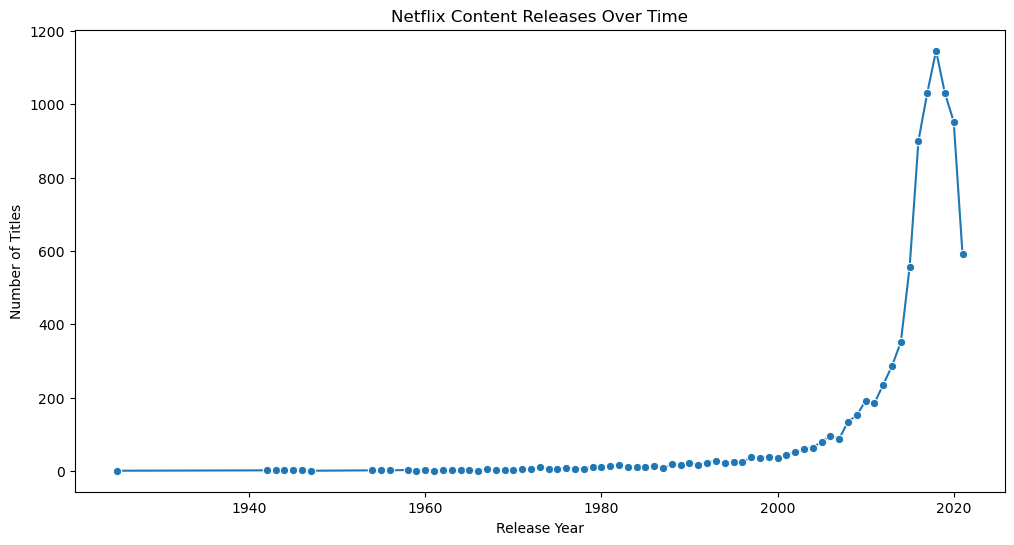

In [10]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df_year, x='release_year', y='count', marker='o')
plt.title("Netflix Content Releases Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

<Figure size 1200x600 with 0 Axes>

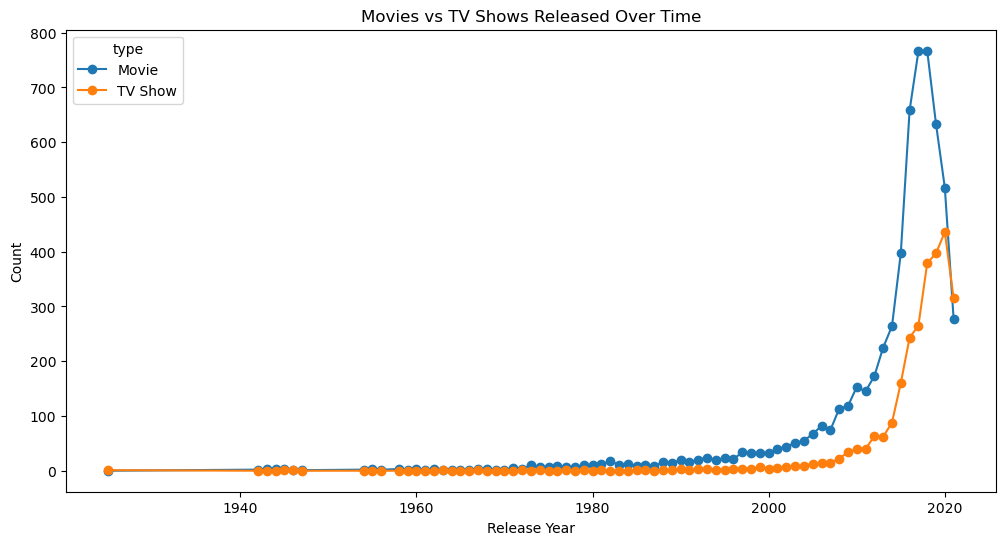

In [11]:
# Compare Movie vs TV Show trend over time
plt.figure(figsize=(12,6))
yearly_type_pivot.plot(kind='line', marker='o', figsize=(12,6))
plt.title("Movies vs TV Shows Released Over Time" , color 'red')
plt.xlabel("Release Year")

plt.ylabel("Count")
plt.show()

In [12]:
year_counts = netflix['year_added'].value_counts()
year_counts

year_added
2019    2016
2020    1879
2018    1649
2021    1498
2017    1187
2016     427
2015      82
2014      24
2011      13
2013      11
2012       3
2009       2
2008       2
2010       1
Name: count, dtype: int64

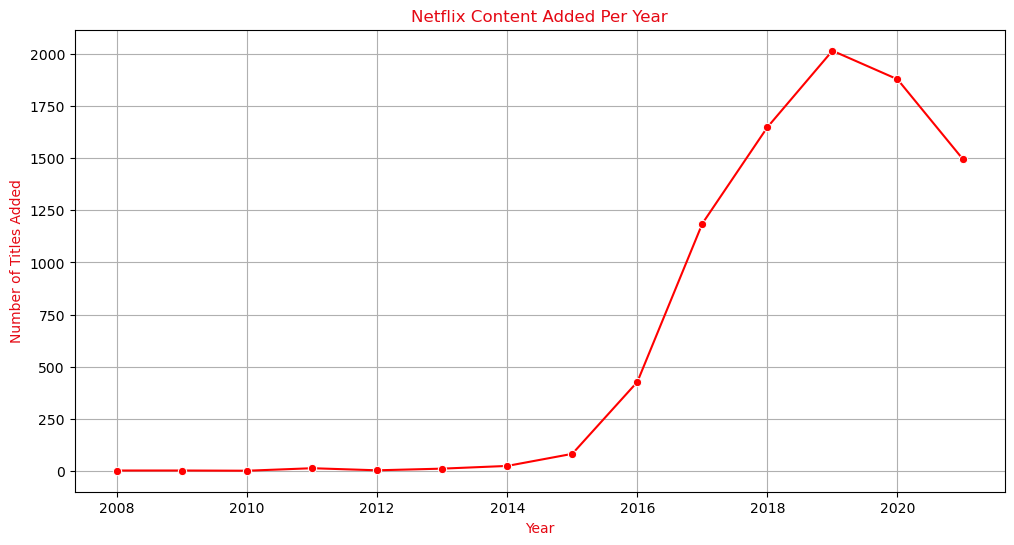

In [13]:
year_trend = year_counts.sort_index()
plt.figure(figsize=(12,6))
sns.lineplot(x=year_trend.index, y=year_trend.values, marker='o' , color = 'red')
plt.title("Netflix Content Added Per Year" , color= '#E50914')
plt.xlabel("Year" , color= '#E50914')
plt.ylabel("Number of Titles Added" , color= '#E50914')
plt.grid(True)   # grid = background lines that make it easier to read exact values
plt.show()

# ✅2019 was the year when most of the netflix content  were released.

In [14]:
month_counts = netflix['month_name_added'].value_counts()
month_counts

month_name_added
July         827
December     813
September    769
April        763
October      760
August       754
March        742
January      738
June         728
November     705
May          632
February     563
Name: count, dtype: int64

C:\Users\Manmohan\AppData\Local\Temp\ipykernel_3640\2854464585.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_trend.index, y=month_trend.values, palette= custom_palette)
C:\Users\Manmohan\AppData\Local\Temp\ipykernel_3640\2854464585.py:7: UserWarning: 
The palette list has fewer values (4) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=month_trend.index, y=month_trend.values, palette= custom_palette)


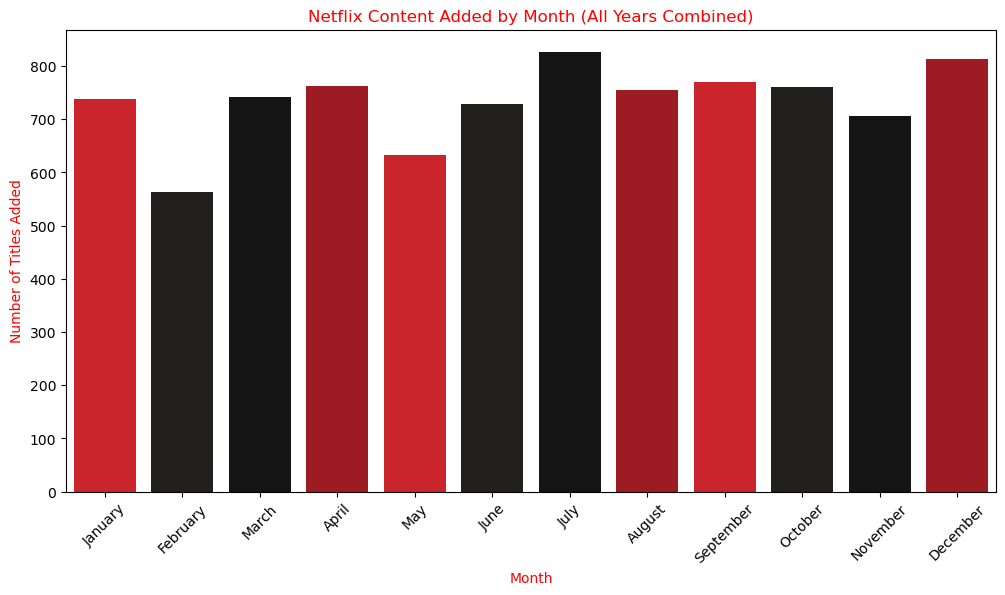

In [15]:
month_trend = month_counts.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(12,6))
sns.barplot(x=month_trend.index, y=month_trend.values, palette= custom_palette)
plt.title("Netflix Content Added by Month (All Years Combined)" , color= 'red')
plt.xlabel("Month" , color = 'red')
plt.ylabel("Number of Titles Added" , color = 'red')
plt.xticks(rotation=45)
plt.show()

# ✅The months of July, December, and September stand out as the top three periods for content releases on Netflix.

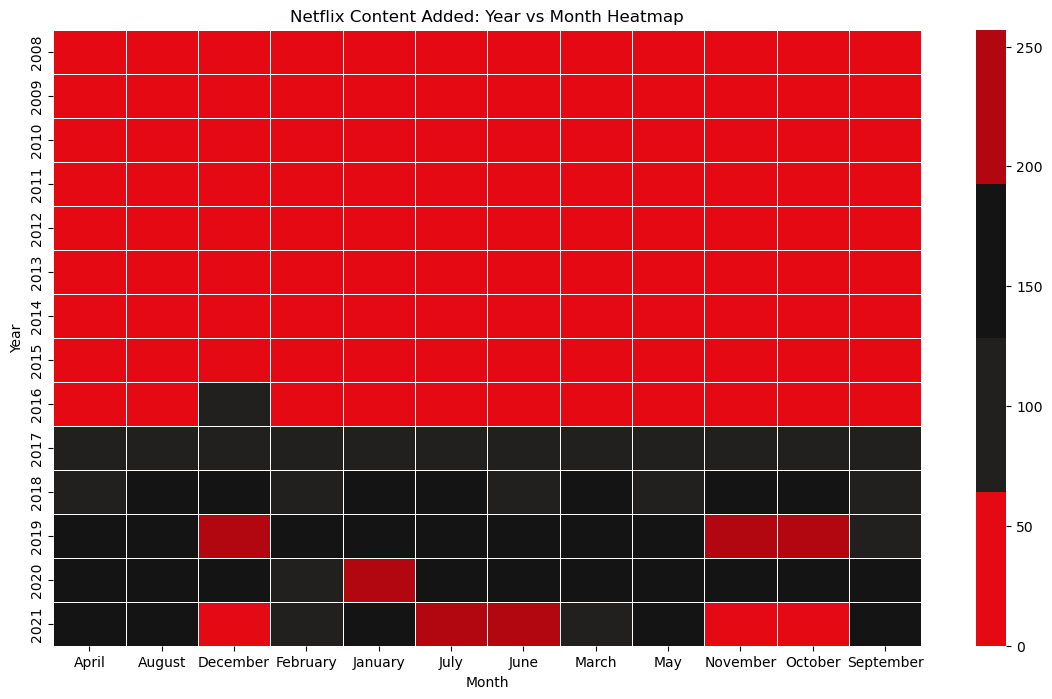

In [16]:
heatmap_data = netflix.groupby(['year_added', 'month_name_added']).size().unstack(fill_value=0)

plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data, cmap=custom_palette, linewidths=0.5, annot=False)
plt.title("Netflix Content Added: Year vs Month Heatmap")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

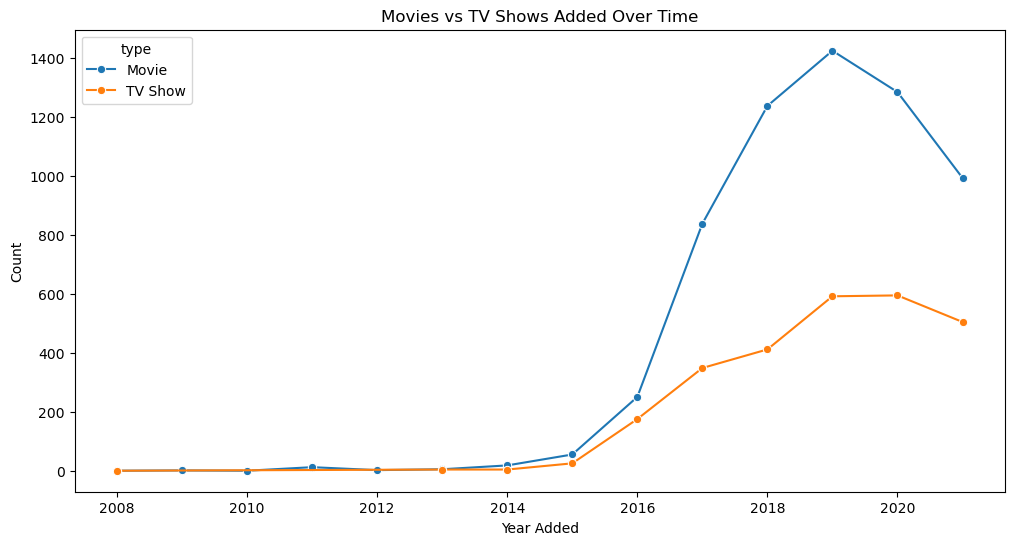

In [17]:
type_year_trend = netflix.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.lineplot(data=type_year_trend, x='year_added', y='count', hue='type', marker='o')
plt.title("Movies vs TV Shows Added Over Time")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.show()

In [18]:
# Identify the peak year (year with maximum content released)
peak_year = df_year.loc[df_year['count'].idxmax(), 'release_year']
peak_count = df_year['count'].max()

print(f"Netflix's peak content release year was {peak_year} with {peak_count} titles.")

# Recent trend (last 5 years in the data, excluding possible incomplete latest year)
recent = df_year.tail(6)
print(recent)

Netflix's peak content release year was 2018 with 1146 titles.
    release_year  count  change  growth_rate_%
68          2016    901   344.0      61.759425
69          2017   1031   130.0      14.428413
70          2018   1146   115.0      11.154219
71          2019   1030  -116.0     -10.122164
72          2020    953   -77.0      -7.475728
73          2021    592  -361.0     -37.880378


 # Interpret business patterns

1) December often shows a spike — Netflix commonly releases more content around holidays for increased viewership.
2) 2019–2020 is usually the peak (highest point) for content added, since Netflix was aggressively expanding its catalog then.
3)   Movies are usually added at a faster/higher rate than TV Shows overall, though TV Show additions may show steadier growth.